In [1]:
from torch import nn
import os
import torch
import numpy as np

from skimage import io
import pickle
import matplotlib.pyplot as plt
from misc import show_imset
from scipy.interpolate import RegularGridInterpolator

# from p9 import Net0312 as Net
# from p10 import Net0312 as Net
from velnet_utils import Net0317 as Net
from my_plots import plot_uvw, plot_vol2

from p1 import read_IJK_from_tecplot_dat
from p1 import XYZTransform

import time 
import shutil
from scipy.io import savemat
from scipy.ndimage import median_filter

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


In [2]:
def transform_piv_data(piv, step, I, J, K, pts__, interp_fill_value=None):
    X = piv[:, 0].reshape((K, J, I))
    Y = piv[:, 1].reshape((K, J, I))
    Z = piv[:, 2].reshape((K, J, I))
    U = piv[:, 3].reshape((K, J, I))
    V = piv[:, 4].reshape((K, J, I))
    W = piv[:, 5].reshape((K, J, I))
    xs = X[0, 0, :]
    ys = Y[0, :, 0]
    zs = Z[:, 0, 0]
    uvw = np.stack([U.transpose(2,1,0), V.transpose(2,1,0), W.transpose(2,1,0)], axis=-1) * step # shape: (I, J, K, 3)
    interp = RegularGridInterpolator((xs, ys, zs), uvw, bounds_error=False, fill_value=interp_fill_value) # fill_value=None, allow extrapolation

    uvw__ = interp(pts__) # interpolation
    u_pts = uvw__[:, 0].reshape(gx__.shape)
    v_pts = uvw__[:, 1].reshape(gx__.shape)
    w_pts = uvw__[:, 2].reshape(gx__.shape)
    uvw_pts = np.stack([u_pts, v_pts, w_pts])

    return uvw_pts

def match_piv_files(data_dict, head_tail):
    f0 = data_dict['f0'] 
    f1 = data_dict['f1']
    step = data_dict['step']

    piv_folder = data_dict['piv_folder']
    piv_files = sorted(os.listdir(piv_folder))[f0:f1][::step]
    
    im_folder = data_dict['im_folder']
    piv_frame0_idx = data_dict['piv_frame0_idx']
    im_files = sorted(os.listdir(im_folder))[piv_frame0_idx+f0-head_tail*step: piv_frame0_idx+f1+head_tail*step][::step]
    
    # get full path
    piv_files = [os.path.join(piv_folder, item) for item in piv_files]
    im_files = [os.path.join(im_folder, item) for item in im_files]

    return piv_files, im_files



def forward_rolling_mean_same_len(arr_list, k=10, dtype=np.float64):
    n = len(arr_list)
    if n == 0:
        return []

    # initial window [0, min(k, n))
    s = np.zeros_like(arr_list[0], dtype=dtype)
    w_end = min(k, n)
    for a in arr_list[:w_end]:
        s += a

    out = []
    for i in range(n):
        count = min(k, n - i)          # partial window at the end
        out.append(s / count)

        # slide window: remove current, add new (if exists)
        s -= arr_list[i]
        j = i + k
        if j < n:
            s += arr_list[j]

    return out



In [3]:
# load the network

result_path = os.path.join(os.getcwd(), 'training_results')

# td_folder = '/zjbd/zd1/dafei/piv_training/jet160'
# training_file = os.path.join(result_path, 'jet160_03-19_22-10', 'net.pt')
# training_file = os.path.join(result_path, 'jet160_03-19_22-12', 'net.pt')
# training_file = os.path.join(result_path, 'jet160_03-19_22-14', 'net.pt')
# td_folder = '/zjbd/zd1/dafei/piv_training/jet128'
# training_file = os.path.join(result_path, 'jet128_03-20_12-48', 'net.pt')

# td_folder = '/zjbd/zd1/dafei/piv_training/jet128roi256'
# training_file = os.path.join(result_path, 'jet128roi256_03-18_18-09', 'net.pt')

# td_folder = '/zjbd/zd1/dafei/piv_training/jet128r2'
# training_file = os.path.join(result_path, 'jet128r2_03-21_01-24', 'net.pt')

# td_folder = '/zjbd/zd1/dafei/piv_training/jet256'
# training_file = os.path.join(result_path, 'jet256_03-21_09-48', 'net.pt')

# td_folder = '/zjbd/zd1/dafei/piv_training/jet256r2'
# training_file = os.path.join(result_path, 'jet256r2_03-21_14-22', 'net.pt')  # current figure is from this
# training_file = os.path.join(result_path, 'jet160_03-23_08-24', 'net.pt')  # large 160 dataset
# training_file = os.path.join(result_path, 'jet256r2_03-23_16-17', 'net.pt') # MSE loss


td_folder = '/zjbd/zd1/dafei/piv_training/jet320r2'
# training_file = os.path.join(result_path, 'jet320r2_03-25_13-47', 'net.pt') # 1600 test


# training_file = os.path.join(result_path, 'jet320r2_03-25_22-44', 'net.pt') # 2000 test

# training_file = os.path.join(result_path, 'jet320_03-24_18-59', 'net.pt')
# training_file = os.path.join(result_path, 'jet256r2_03-24_21-09', 'net.pt')

# training_file = os.path.join(result_path, 'jet320r2_03-26_17-38', 'net.pt')

training_file = os.path.join(result_path, 'jet320r3_03-26_22-27', 'net.pt')


vol_dict = dict(vol_nc=64, vol_nz=100, vol_ds=(1, 4, 2), ds_zyx=(4, 16, 16))
cv_dict = dict(win=(19, 9, 19), cv_ds = (4, 4, 8))
dt1_dict = dict(use=True, step=1, md_zyx=(1, 2, 2), cv_nc=64)
dt2_dict = dict(use=True, step=2, md_zyx=(2, 3, 3), cv_nc=64)
net = Net(5, vol_dict, cv_dict, dt1_dict, dt2_dict).to(device)



x_folder = os.path.join(td_folder, 'x')
y_folder = os.path.join(td_folder, 'y')
y_list = sorted(os.listdir(y_folder))

checkpoint = torch.load(training_file, map_location=device, weights_only=False)
net.load_state_dict(checkpoint['state_dict'])
net.to(device)

with open(os.path.join(td_folder, 'labels.pickle'), 'rb') as handle:
    labels = pickle.load(handle)



image volume downsampling: (1, 4, 2), cv downsampling: (4, 4, 8), head downsampling: (1, 1, 1)
dt1 cost volume channels: 75
dt2 cost volume channels: 245


In [4]:
data_tags = labels['data_tags']
validation_tags = data_tags[2:3]
# validation_tags = data_tags[3:4]
print(f'data tags: {data_tags}. test data tag: {validation_tags}')

validation = [s for s in y_list if any(p in s for p in validation_tags)]
validation = validation[::2]

print(f'y # :{len(y_list)}')
print(f'validation: {len(validation)}')

data tags: ['d1200jet1step1', 'd1200jet2step1', 'd1600jet1step1', 'd2000jet1step1']. test data tag: ['d1600jet1step1']
y # :73500
validation: 11375


# of images in input: 11


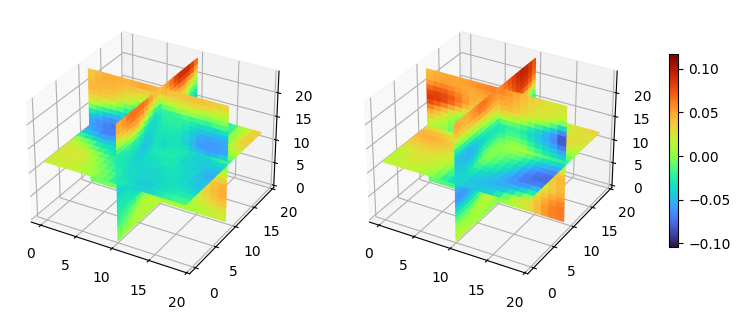

0.7784690480056268


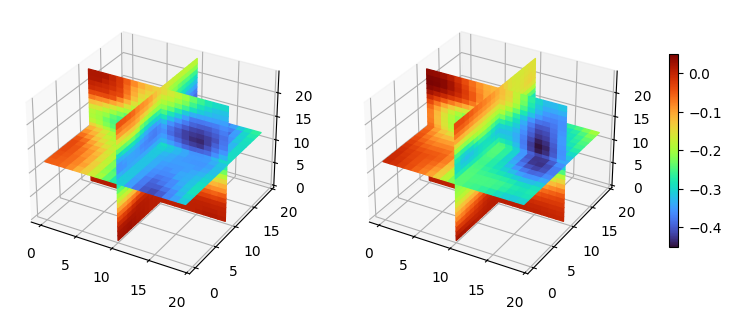

0.9621142930548422


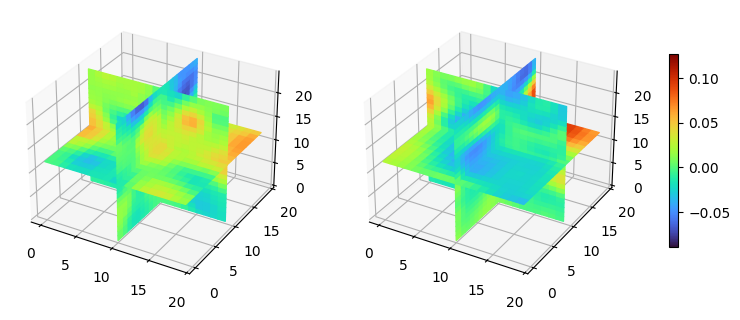

0.4890802305897504


In [5]:
# use one test sample
test_idx = 100
yfile = validation[test_idx]
imfiles = labels[yfile]
print(f'# of images in input: {len(imfiles)}')

# nt=5
# t0 = 5 - nt + 1
# t1 = t0 + 2*nt
# imfiles = imfiles[t0:t1:2]

imfiles = imfiles[5-2:5+3]



ims = np.stack([io.imread(os.path.join(x_folder, file)) for file in imfiles])
x = (ims/255.0).astype(np.float32)[np.newaxis, :, :, :]
y = np.load(os.path.join(y_folder, yfile))

net.eval()
with torch.set_grad_enabled(False):
    ys_pred = net(torch.tensor(x, device=device))[0].cpu().numpy()
    ys_pred = median_filter(ys_pred, size=(1, 3, 3, 3))

    

# show results
plot_vol2(ys_pred[0], y[0])
print(np.corrcoef(ys_pred[0].ravel(), y[0].ravel())[0, 1])
plot_vol2(ys_pred[1], y[1])
print(np.corrcoef(ys_pred[1].ravel(), y[1].ravel())[0, 1])
plot_vol2(ys_pred[2], y[2])
print(np.corrcoef(ys_pred[2].ravel(), y[2].ravel())[0, 1])

In [6]:
# load ground truth

center_x = 1061 
center_y = 1092
pixel_size = 0.0392
alignment_file = 'alignment16_0127_1000.npy'  # tp16, new net, FOV 1000
alignment_dict = np.load(alignment_file, allow_pickle=True).item()
A = np.concatenate((alignment_dict['affine3x4'], np.array([[0, 0, 0, 1]])), axis=0)
xyzfunc = XYZTransform(alignment_dict)   # more elaborated transform

im_relative_ids = labels['im_relative_ids']
head_tail = labels['head_tail']


# im_relative_ids = im_relative_ids[t0:t1:2]
im_relative_ids = im_relative_ids[5-2:5+3]


dd_d1600jet1step1 = dict(
    data_title = 'd1600jet1step1',
    piv_folder = '/zjbd/zd1/dafei/PIV_data/TOMO/exp20251216/D1600_TP_Jet_R1/TomographicPIV_48x48x48_75%ov_100_800/TomoPostProcessing/SlidAvg L=5',
    piv_frame0_idx = 99, 
    im_folder = '/zjbd/zd1/dafei/PIV_data/PSFE/exp20251216/D1600_TP_Jet_R1',
    f0 = 10,  # 150
    f1 = 690,  # 600
    # f0 = 150,  # 150
    # f1 = 600,  # 600
    step = 1,
    roi_cropping_shift = 64,
)


dd_d2000jet1step1 = dict(
    data_title = 'd2000jet1step1',
    piv_folder = '/zjbd/zd1/dafei/PIV_data/TOMO/exp20251216/D2000_TP_Jet_R1/TomographicPIV_48x48x48_75%ov_100_500/SlidAvg L=5',
    piv_frame0_idx = 99, 
    im_folder = '/zjbd/zd1/dafei/PIV_data/PSFE/exp20251216/D2000_TP_Jet_R1',
    f0 = 10,
    f1 = 390,
    step = 1,
    roi_cropping_shift = 64,  # 96
)


dd_d2000jet2step1 = dict(
    data_title = 'd2000jet2step1',
    piv_folder = '/zjbd/zd1/dafei/PIV_data/TOMO/exp20251216/D2000_TP_Jet_R2/TomographicPIV_48x48x48_75%ov_400_1400/SlidAvg L=5',
    piv_frame0_idx = 399, 
    im_folder = '/zjbd/zd1/dafei/PIV_data/PSFE/exp20251216/D2000_TP_Jet_R2',
    f0 = 100,
    f1 = 900,
    step = 1,
    roi_cropping_shift = 64,  # 48

)

dd = dd_d1600jet1step1
# dd = dd_d2000jet1step1




piv_files, im_files = match_piv_files(dd, head_tail)
I, J, K = read_IJK_from_tecplot_dat(piv_files[0])

num_piv_files = len(piv_files)
num_im_files = len(im_files)

print(f'voxels of the tomo data: I-{I}, J-{J}, K-{K}')
print(f'# of piv files: {num_piv_files}')
print(f'# of images: {num_im_files}')




voxels of the tomo data: I-55, J-55, K-27
# of piv files: 680
# of images: 690


In [7]:
# prepare 3D grid in PSFE space and map to tomo space
# xy
hh, ww = 800, 640  # devisible by de_m
# hh, ww = 768, 512  # devisible by de_m

# set z range in psfe space such that the corresponding tomo space has a proper z range
z0 = labels['z0']
z1 = labels['z1']

de_m = labels['de_m']  # demagnification in x and y
K_ = labels['K_']
I_, J_ = int(ww/de_m), int(hh/de_m)  # 3D voxelization of the volume
print(f'voxels of the PSFE volume: I_-{I_}, J_-{J_}, K_-{K_}')

# 3D grid in PSFE space
xy05 = pixel_size*ww/2
w05, h05 = ww//2, hh//2
r0, r1 = center_y-h05, center_y+h05   # cropping ends
c0, c1 = center_x-w05, center_x+w05  # cropping ends
x0 = (c0-center_x)*pixel_size  # left, negative x
x1 = (c1-center_x)*pixel_size  # right, positive x
y0 = (center_y-r0)*pixel_size  # up, positive y
y1 = (center_y-r1)*pixel_size  # down, negative y
print(f'PSFE roi: x range ({x0}, {x1}), y range ({y0}, {y1}), zrange ({z0}, {z1})')

# coordinate transform
xx = np.linspace(x0, x1, I_) 
yy = np.linspace(y0, y1, J_)
zz = np.linspace(z0, z1, K_)
gx, gy, gz = np.meshgrid(xx, yy, zz, indexing='xy')   # indexing should be xy 
pts = np.c_[gx.flatten(), gy.flatten(), gz.flatten()]
# pts_ = (A @ np.c_[(pts, np.ones((pts.shape[0], 1)))].T)[:3, :].T  # affine transform
pts_ = xyzfunc.direct_transform(pts)  # transform to tomo space
gx_ = pts_[:, 0].reshape(gx.shape).transpose(2, 0, 1)  # reshape to K_, J_, I_
gy_ = pts_[:, 1].reshape(gx.shape).transpose(2, 0, 1)
gz_ = pts_[:, 2].reshape(gx.shape).transpose(2, 0, 1)
gx__ = gx_  # z filtering can be done here
gy__ = gy_
gz__ = gz_
pts__ = np.c_[gx__.flatten(), gy__.flatten(), gz__.flatten()]  # important

voxels of the PSFE volume: I_-40, J_-50, K_-25
PSFE roi: x range (-12.544, 12.544), y range (15.68, -15.68), zrange (0.4, 18.2)


1.1005921363830566


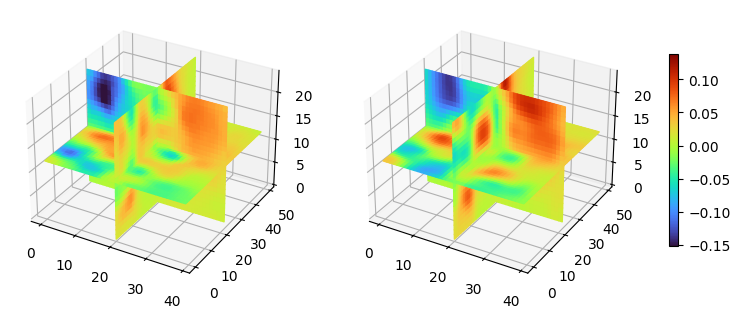

0.8955805183859339


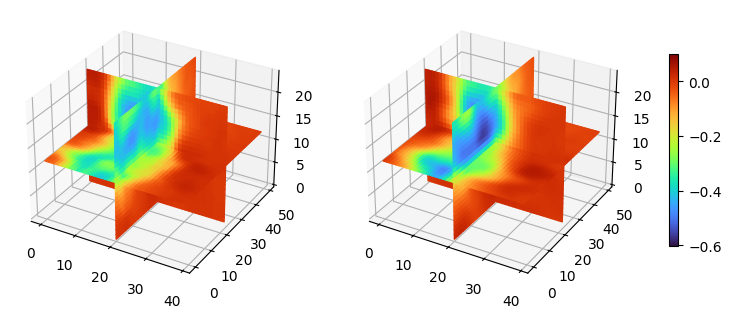

0.9670456927210439


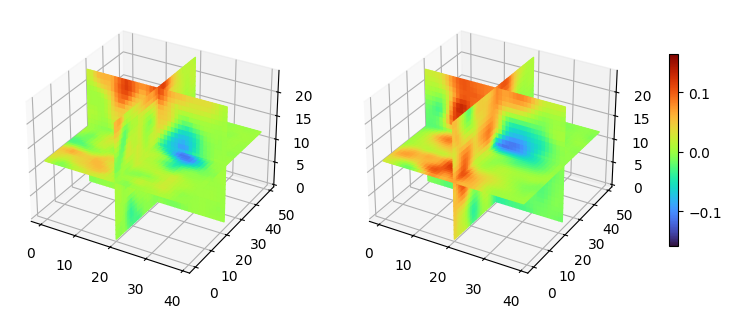

0.774585798104808


In [8]:
# piv_idx = 350
piv_idx = 150

step = dd['step']
piv = np.loadtxt(piv_files[piv_idx], skiprows=4)
uvw_pts = transform_piv_data(piv, step, I, J, K, pts__)
im_idx = piv_idx+head_tail
ims = [io.imread(im_files[im_idx+i])[r0:r1, c0:c1] for i in im_relative_ids]
ims = np.array(ims).astype(np.float32)/255.0150


patch_size = (800, 640)  # (height, width)
# patch_size = (160, 160)

uvw_size = (int(patch_size[0]/de_m), int(patch_size[1]/de_m))
x = ims[np.newaxis, :, :patch_size[0], :patch_size[1]]
net.eval()
with torch.set_grad_enabled(False):
    t0 = time.time()
    ys_pred = net(torch.tensor(x, device=device))[0].cpu().numpy()
    t1 = time.time()
    print(t1-t0)
    ys_pred = median_filter(ys_pred, size=(1, 3, 3, 3))
y = uvw_pts[:, :, :uvw_size[0], :uvw_size[1]]


# show results
plot_vol2(ys_pred[0], y[0])
print(np.corrcoef(ys_pred[0].ravel(), y[0].ravel())[0, 1])
plot_vol2(ys_pred[1], y[1])
print(np.corrcoef(ys_pred[1].ravel(), y[1].ravel())[0, 1])
plot_vol2(ys_pred[2], y[2])
print(np.corrcoef(ys_pred[2].ravel(), y[2].ravel())[0, 1])

row: 1, col: 1
1.0994181632995605


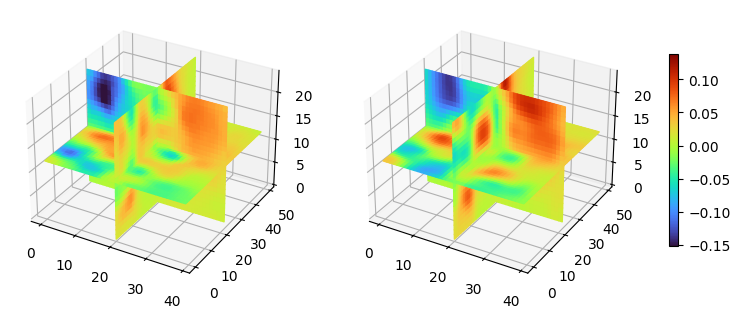

0.8955805183859339


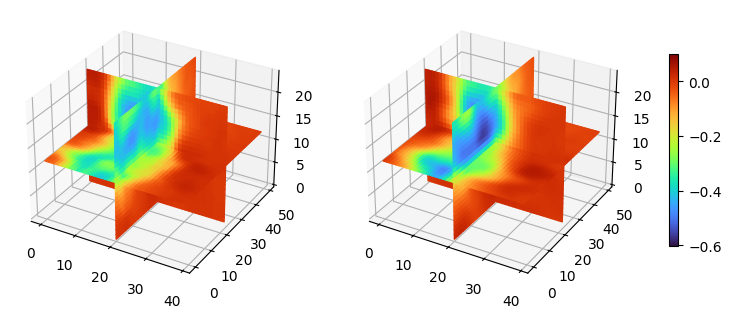

0.9670456927210439


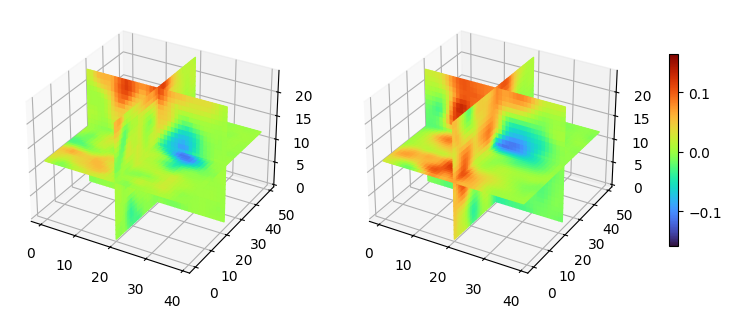

0.774585798104808


In [17]:
C = ims.shape[0]
nh = hh // patch_size[0]
nw = ww // patch_size [1]

print(f'row: {nh}, col: {nw}')

hh2, ww2 = nh * patch_size[0], nw * patch_size[1]
ims_new = ims[:, :hh2, :ww2].copy()

patches = ims_new.reshape(C, nh, patch_size[0], nw, patch_size[1]).transpose(1, 3, 0, 2, 4)
x = patches.reshape(nh*nw, C, patch_size[0], patch_size[1])
net.eval()
with torch.set_grad_enabled(False):
    t0 = time.time()
    ys_pred = net(torch.tensor(x, device=device)).cpu().numpy()
    t1 = time.time()
    print(t1-t0)
    
# assemble
ys_pred = ys_pred.reshape(nh, nw, 3, K_, uvw_size[0], uvw_size[1])
ys_pred = ys_pred.transpose(2, 3, 0, 4, 1, 5).reshape(3, K_, nh * uvw_size[0], nw * uvw_size[1])
ys_pred = median_filter(ys_pred, size=(1, 3, 3, 3))

y = uvw_pts[:, :, :uvw_size[0]*nh, :uvw_size[1]*nw]

plot_vol2(ys_pred[0], y[0])
print(np.corrcoef(ys_pred[0].ravel(), y[0].ravel())[0, 1])
plot_vol2(ys_pred[1], y[1])
print(np.corrcoef(ys_pred[1].ravel(), y[1].ravel())[0, 1])
plot_vol2(ys_pred[2], y[2])
print(np.corrcoef(ys_pred[2].ravel(), y[2].ravel())[0, 1])